# 🌀 Fase e movimento — a Transformada de Hilbert
por: **Iury Coelho**

No notebook 10, o I e o Q vinham prontos do hardware de rádio. Mas e quando temos
**só um sinal real** — um microfone, um sensor de uma componente só? Temos o
"cosseno", sem o "seno" companheiro.

A **Transformada de Hilbert** resolve isso: ela cria a componente em
**quadratura** (defasada em 90°) que falta, formando o **sinal analítico**
$$ z(t) = x(t) + j\,\mathcal{H}\{x(t)\} = a(t)\,e^{j\phi(t)}. $$
Daí lemos diretamente o **envelope** $a(t) = |z(t)|$ e a **fase / frequência
instantânea** — exatamente o que precisamos para extrair *movimento* de sinais
reais. É o complemento do nb10: lá o I/Q veio pronto; aqui nós o **fabricamos**.

#### Conteúdo
* [1. O sinal analítico](#1)
* [2. Envelope: o contorno de amplitude](#2)
* [3. Frequência instantânea](#3)
* [4. Sensing: respiração de um sinal real](#4)
* [5. Da simulação ao mundo real](#5)
* [6. Exercício](#6)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as ss

plt.rcParams["figure.figsize"] = (9, 3.4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

def espectro(x, fs):
    X = np.abs(np.fft.rfft(x)) / len(x) * 2
    f = np.fft.rfftfreq(len(x), 1/fs)
    return f, X

<a id="1"></a>
## 1. O sinal analítico

`scipy.signal.hilbert` devolve o sinal analítico já montado: $z = x + j\,
\mathcal{H}\{x\}$. Para um cosseno, a Transformada de Hilbert produz um **seno**
— ou seja, a tal componente em quadratura. Repare que o **envelope** $|z|$ de um
cosseno puro é constante (= 1): não há modulação.

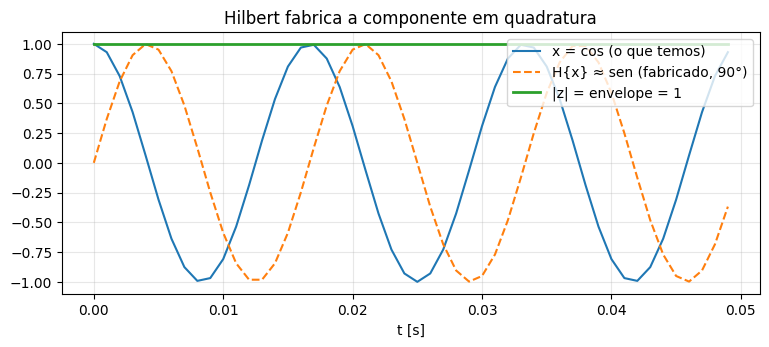

In [2]:
fs = 1000
t = np.arange(0, 0.05, 1/fs)
x = np.cos(2*np.pi*60*t)
z = ss.hilbert(x)          # sinal analitico: x + j*H{x}

plt.plot(t, x, label="x = cos (o que temos)")
plt.plot(t, z.imag, "--", label="H{x} ≈ sen (fabricado, 90°)")
plt.plot(t, np.abs(z), "C2", lw=2, label="|z| = envelope = 1")
plt.title("Hilbert fabrica a componente em quadratura")
plt.xlabel("t [s]"); plt.legend(loc="upper right"); plt.show()

<a id="2"></a>
## 2. Envelope: o contorno de amplitude

Aqui Hilbert brilha. Um sinal **modulado em amplitude** (uma portadora rápida cuja
*força* varia devagar) tem o seu "contorno" — o **envelope** — escondido. O
módulo do sinal analítico recupera esse contorno na hora, sem filtro nenhum.

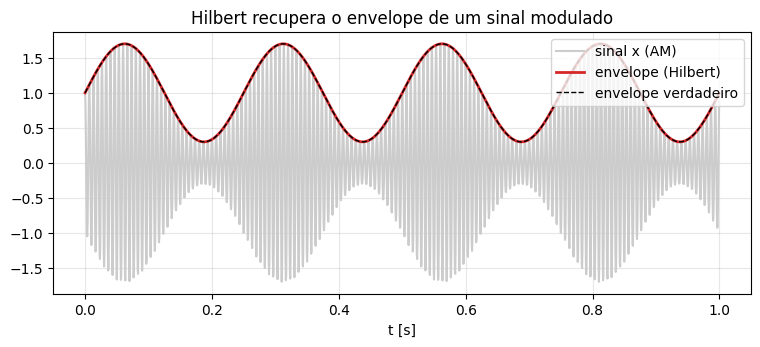

In [3]:
fs = 2000
t = np.arange(0, 1, 1/fs)
envelope_real = 1 + 0.7*np.sin(2*np.pi*4*t)        # contorno lento (4 Hz)
x = envelope_real * np.cos(2*np.pi*150*t)          # portadora de 150 Hz

env = np.abs(ss.hilbert(x))                        # envelope recuperado

plt.plot(t, x, "0.8", label="sinal x (AM)")
plt.plot(t, env, "C3", lw=2, label="envelope (Hilbert)")
plt.plot(t, envelope_real, "k--", lw=1, label="envelope verdadeiro")
plt.title("Hilbert recupera o envelope de um sinal modulado")
plt.xlabel("t [s]"); plt.legend(loc="upper right"); plt.show()

<a id="3"></a>
## 3. Frequência instantânea

A **fase** do sinal analítico, desenrolada com `unwrap`, cresce com o tempo; sua
**derivada** é a **frequência instantânea** — quantos hertz o sinal tem *a cada
momento*. É a "linha" que vimos no espectrograma (nb09), agora como um número por
instante. Num **chirp**, ela sobe em linha reta.

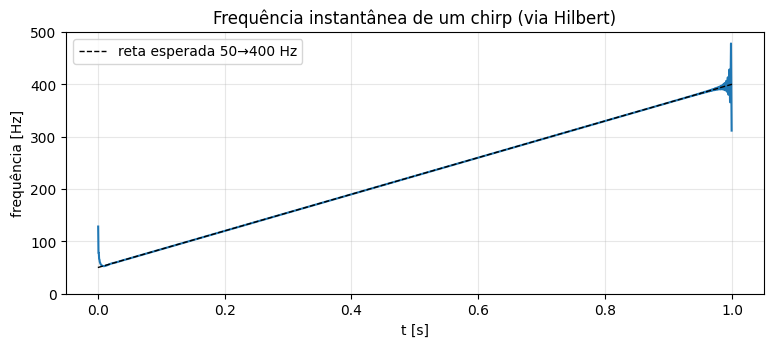

In [4]:
fs = 2000
t = np.arange(0, 1, 1/fs)
chirp = ss.chirp(t, f0=50, f1=400, t1=1.0, method="linear")

fase = np.unwrap(np.angle(ss.hilbert(chirp)))
freq_inst = np.diff(fase) / (2*np.pi) * fs          # Hz, por instante

plt.plot(t[1:], freq_inst, "C0")
plt.plot([0, 1], [50, 400], "k--", lw=1, label="reta esperada 50→400 Hz")
plt.ylim(0, 500)
plt.title("Frequência instantânea de um chirp (via Hilbert)")
plt.xlabel("t [s]"); plt.ylabel("frequência [Hz]"); plt.legend(); plt.show()

<a id="4"></a>
## 4. Sensing: respiração de um sinal real

O elo com o sensoriamento. Imagine um sensor que entrega um **sinal real** cuja
*amplitude* é modulada pela respiração (o movimento do peito altera a intensidade
da reflexão). Não temos I/Q — mas Hilbert extrai o **envelope**, e nele está a
respiração. Uma FFT do envelope dá o ritmo.

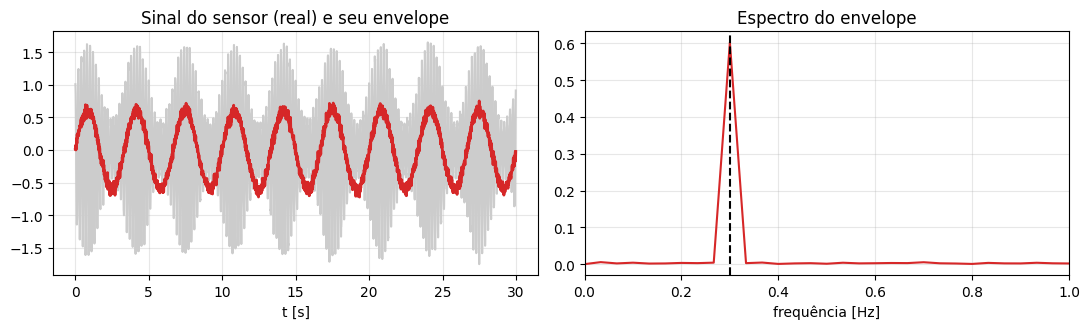

Respiração estimada (via envelope de Hilbert): 18.0 por minuto


In [5]:
fs = 100.0
dur = 30.0
t = np.arange(0, dur, 1/fs)
rng = np.random.default_rng(0)

f_resp = 0.30                                   # 18/min
modul = 1 + 0.6*np.sin(2*np.pi*f_resp*t)        # respiracao modula a amplitude
sensor = modul * np.cos(2*np.pi*5*t)            # sinal real do sensor
sensor += 0.05*rng.standard_normal(len(t))

env = np.abs(ss.hilbert(sensor))
env = env - env.mean()                          # remove o nivel DC

f, X = espectro(env, fs)
faixa = (f >= 0.1) & (f <= 0.6)
rpm = f[faixa][np.argmax(X[faixa])] * 60

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(t, sensor, "0.8"); a1.plot(t, env + 0, "C3", lw=2)
a1.set_title("Sinal do sensor (real) e seu envelope"); a1.set_xlabel("t [s]")
a2.plot(f, X, "C3"); a2.set_xlim(0, 1.0); a2.axvline(rpm/60, color="k", ls="--")
a2.set_title("Espectro do envelope"); a2.set_xlabel("frequência [Hz]")
plt.tight_layout(); plt.show()
print(f"Respiração estimada (via envelope de Hilbert): {rpm:.1f} por minuto")

<a id="5"></a>
## 5. Da simulação ao mundo real

A Transformada de Hilbert é uma ferramenta-chave de demodulação e análise de
envelope — usada em rádio (AM/FM), áudio, vibração e sensoriamento. Em sistemas
como o RuView ela ajuda a transformar medidas reais em **amplitude e fase
instantâneas**, de onde saem movimento, respiração e batimento.

> ⚠️ Didático. Hilbert tem **efeitos de borda** (note as pontas do gráfico de
> frequência instantânea) e pressupõe sinais de **banda estreita** para o
> envelope fazer sentido — cuidados que sistemas reais tratam com janelas e
> filtragem.

Agora você sabe **fabricar o I/Q** de qualquer sinal real — o par perfeito do
notebook 10. 🚀

<a id="6"></a>
## 6. Exercício

__Exercício__ — Duas perguntas reveladoras. **(a)** Mantenha a respiração fraca
(`prof = 0.05`) e aumente o **ruído branco** até `1.0` (vinte vezes o sinal!). A
estimativa aguenta? **(b)** Agora, em vez de ruído, some uma **interferência na
mesma faixa** — um movimento corporal lento perto de 15/min (`interf` em
0,25 Hz). O que acontece com a estimativa?

In [6]:
def estimar(prof, ruido, interf=0.0, f_interf=0.25, seed=1):
    rng = np.random.default_rng(seed)
    modul = 1 + prof*np.sin(2*np.pi*0.30*t) + interf*np.sin(2*np.pi*f_interf*t)
    s = modul*np.cos(2*np.pi*5*t) + ruido*rng.standard_normal(len(t))
    env = np.abs(ss.hilbert(s)); env = env - env.mean()
    f, X = espectro(env, fs)
    faixa = (f >= 0.1) & (f <= 0.6)
    return f[faixa][np.argmax(X[faixa])] * 60

print("respiração real = 18/min\n")
print(f"(a) ruído branco 20x o sinal:     prof=0.05, ruído=1.0   -> {estimar(0.05, 1.0):.1f}/min")
print(f"(b) interferência fraca na faixa: prof=0.05, interf=0.10 -> {estimar(0.05, 0.05, 0.10):.1f}/min")
print(f"    respiração forte resiste:     prof=0.30, interf=0.10 -> {estimar(0.30, 0.05, 0.10):.1f}/min")

respiração real = 18/min

(a) ruído branco 20x o sinal:     prof=0.05, ruído=1.0   -> 18.0/min
(b) interferência fraca na faixa: prof=0.05, interf=0.10 -> 14.0/min
    respiração forte resiste:     prof=0.30, interf=0.10 -> 18.0/min


__Resposta__: **(a)** O ruído branco, mesmo 20× mais forte, **não engana**: a FFT
soma a respiração coerentemente ao longo de muitos ciclos, enquanto o ruído se
espalha por todas as frequências. É o **ganho de processamento** — quanto mais
longa a observação, mais o sinal periódico se destaca do ruído. É por isso que
sensing por rádio funciona mesmo com sinais fraquíssimos. **(b)** Já uma
**interferência na mesma faixa** (outro movimento periódico) é o inimigo de
verdade: com a respiração fraca, a estimativa "pula" para a frequência da
interferência (~15/min), não os 18 reais — mas uma respiração forte resiste.
Por isso sistemas reais separam alvos com **mais antenas, rastreamento no tempo e
modelos**, não com mais potência.

---
<br>[⬆ volte ao topo](#Conteúdo)